#**Business Problem**


The Management team at Walmart Inc. wants to analyze the customer purchase behavior (specifically, purchase amount) against the customer’s gender and the various other factors to help the business make better decisions. They want to understand if the spending habits differ between male and female customers: Do women spend more on Black Friday than men? (Assume 50 million customers are male and 50 million are female).



In [ ]:
# importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#**LOAD DATA & BASIC STRUCTURE CHECKS**

In [ ]:
!gdown https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/293/original/walmart_data.csv

Downloading...
From: https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/293/original/walmart_data.csv
To: /content/walmart_data.csv
100% 23.0M/23.0M [00:00<00:00, 178MB/s]


In [ ]:
df = pd.read_csv("walmart_data.csv")
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


In [ ]:
df.shape

(550068, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype   
---  ------                      --------------   -----   
 0   User_ID                     550068 non-null  int64   
 1   Product_ID                  550068 non-null  object  
 2   Gender                      550068 non-null  category
 3   Age                         550068 non-null  category
 4   Occupation                  550068 non-null  int64   
 5   City_Category               550068 non-null  category
 6   Stay_In_Current_City_Years  550068 non-null  category
 7   Marital_Status              550068 non-null  category
 8   Product_Category            550068 non-null  category
 9   Purchase                    550068 non-null  float64 
dtypes: category(6), float64(1), int64(2), object(1)
memory usage: 19.9+ MB


In [ ]:
categorical_cols = [
    'Gender',
    'Age',
    'City_Category',
    'Stay_In_Current_City_Years',
    'Marital_Status',
    'Product_Category'
]

for col in categorical_cols:
    df[col] = df[col].astype('category')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype   
---  ------                      --------------   -----   
 0   User_ID                     550068 non-null  int64   
 1   Product_ID                  550068 non-null  object  
 2   Gender                      550068 non-null  category
 3   Age                         550068 non-null  category
 4   Occupation                  550068 non-null  int64   
 5   City_Category               550068 non-null  category
 6   Stay_In_Current_City_Years  550068 non-null  category
 7   Marital_Status              550068 non-null  category
 8   Product_Category            550068 non-null  category
 9   Purchase                    550068 non-null  float64 
dtypes: category(6), float64(1), int64(2), object(1)
memory usage: 19.9+ MB


Converted categorical columns into category datatype for better memory optimization and efficient analysis. This also improves plotting and grouping operations during exploratory data analysis.

In [ ]:
df.nunique()

,0
User_ID,5891
Product_ID,3631
Gender,2
Age,7
Occupation,21
City_Category,3
Stay_In_Current_City_Years,5
Marital_Status,2
Product_Category,20
Purchase,18105


In [ ]:
df.isnull().sum()

,0
User_ID,0
Product_ID,0
Gender,0
Age,0
Occupation,0
City_Category,0
Stay_In_Current_City_Years,0
Marital_Status,0
Product_Category,0
Purchase,0


In [ ]:
df.describe()

,User_ID,Occupation,Marital_Status,Product_Category,Purchase
count,5.500680e+05,550068.000000,550068.000000,550068.000000,550068.000000
mean,1.003029e+06,8.076707,0.409653,5.404270,9263.968713
std,1.727592e+03,6.522660,0.491770,3.936211,5023.065394
min,1.000001e+06,0.000000,0.000000,1.000000,12.000000
25%,1.001516e+06,2.000000,0.000000,1.000000,5823.000000
50%,1.003077e+06,7.000000,0.000000,5.000000,8047.000000
75%,1.004478e+06,14.000000,1.000000,8.000000,12054.000000
max,1.006040e+06,20.000000,1.000000,20.000000,23961.000000


In [ ]:
# Gender Distribution
print(df['Gender'].value_counts())

# Age Distribution
print(df['Age'].value_counts())

# Marital Status Distribution
print(df['Marital_Status'].value_counts())

# City Category Distribution
print(df['City_Category'].value_counts())

Gender
M    414259
F    135809
Name: count, dtype: int64
Age
26-35    219587
36-45    110013
18-25     99660
46-50     45701
51-55     38501
55+       21504
0-17      15102
Name: count, dtype: int64
Marital_Status
0    324731
1    225337
Name: count, dtype: int64
City_Category
B    231173
C    171175
A    147720
Name: count, dtype: int64


Male customers form the majority of Walmart’s Black Friday transactions.

Customers aged 26–35 contribute the highest number of purchases, indicating this segment is Walmart’s primary shopping demographic.

Most transactions originate from City Category B, suggesting stronger customer concentration in mid-sized cities.

Unmarried customers contribute slightly more transactions than married customers.

In [ ]:
df.describe(include='object')

,Product_ID,Gender,Age,City_Category,Stay_In_Current_City_Years
count,550068,550068,550068,550068,550068
unique,3631,2,7,3,5
top,P00265242,M,26-35,B,1
freq,1880,414259,219587,231173,193821


# **OUTLIER DETECTION & TREATMENT**

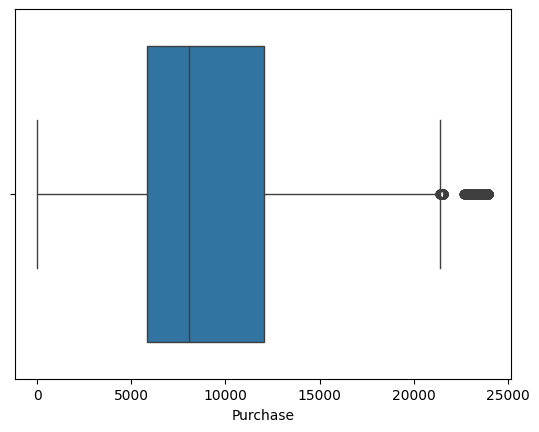

In [ ]:
sns.boxplot( x=df ['Purchase'])
plt.show()

In [ ]:
Q1_Purchase = df["Purchase"].quantile(0.25)
Q3_Purchase = df["Purchase"].quantile(0.75)
IQR_Purchase = Q3_Purchase - Q1_Purchase
upper_bound_Purchase = Q3_Purchase + 1.5 * IQR_Purchase
lower_bound_Purchase = Q1_Purchase - 1.5 * IQR_Purchase
df[df['Purchase'] > upper_bound_Purchase]

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
343,1000058,P00117642,M,26-35,2,B,3,0,10,23603
375,1000062,P00119342,F,36-45,3,A,1,0,10,23792
652,1000126,P00087042,M,18-25,9,B,1,0,10,23233
736,1000139,P00159542,F,26-35,20,C,2,0,10,23595
1041,1000175,P00052842,F,26-35,2,B,1,0,10,23341
...,...,...,...,...,...,...,...,...,...,...
544488,1005815,P00116142,M,26-35,20,B,1,0,10,23753
544704,1005847,P00085342,F,18-25,4,B,2,0,10,23724
544743,1005852,P00202242,F,26-35,1,A,0,1,10,23529
545663,1006002,P00116142,M,51-55,0,C,1,1,10,23663


In [ ]:
df["Purchase"] = df["Purchase"].clip(lower_bound_Purchase, upper_bound_Purchase)

Outliers were capped using the IQR method instead of removing them completely because extremely high purchase values may represent genuine customer behavior during Black Friday sales. Capping helps reduce skewness while preserving valuable business information.

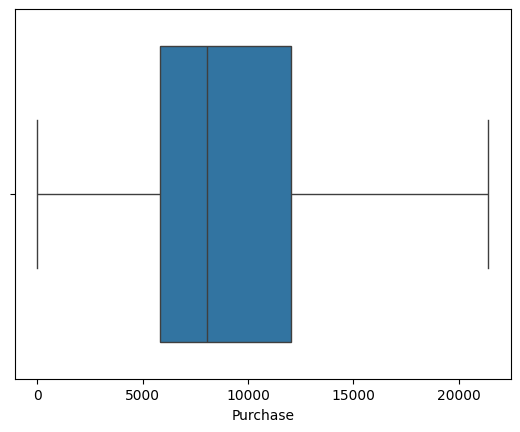

In [ ]:
sns.boxplot( x=df ['Purchase'])
plt.show()

# ** DATA EXPLORATION (EDA)**

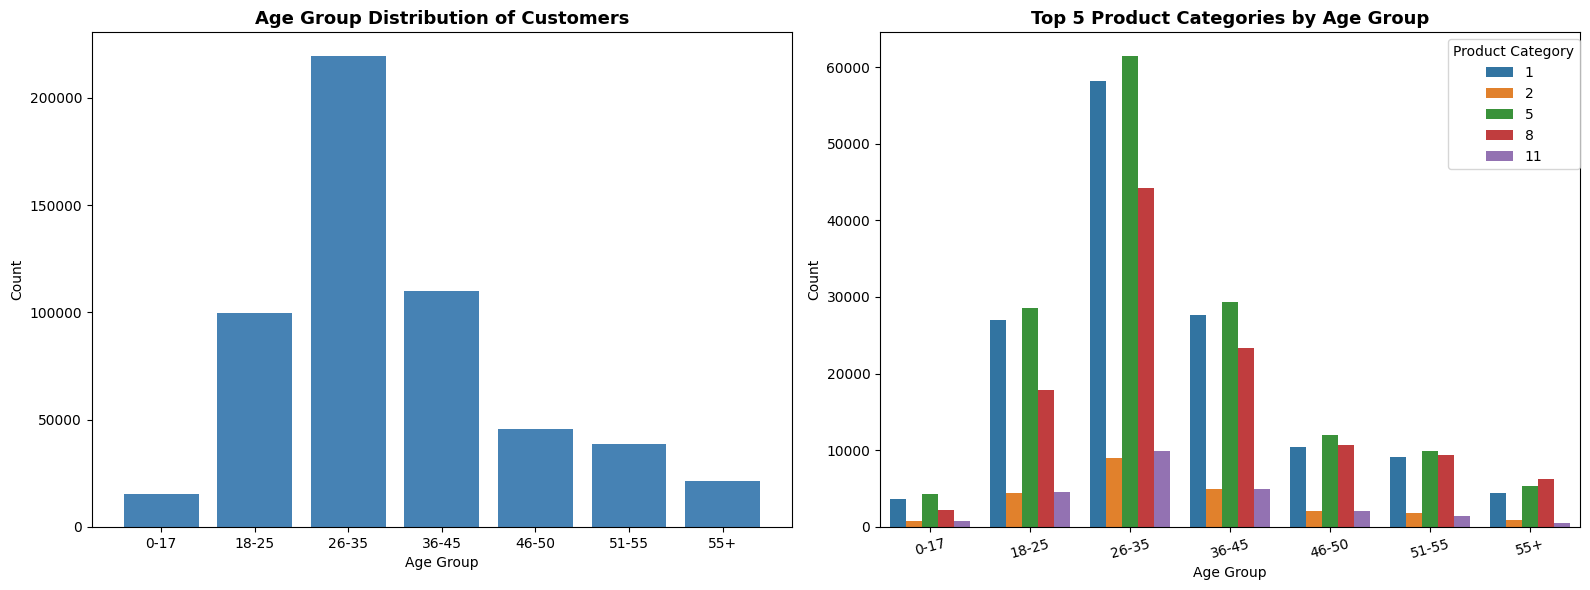

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Age distribution
age_order_plot = ['0-17', '18-25', '26-35', '36-45', '46-50', '51-55', '55+']
age_counts = df['Age'].value_counts().reindex(age_order_plot)
axes[0].bar(age_order_plot, age_counts.values, color='steelblue')
axes[0].set_title("Age Group Distribution of Customers", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Count")

# Top 5 product categories per age group
top_cats = df['Product_Category'].value_counts().head(5).index
age_prod = df[df['Product_Category'].isin(top_cats)]
age_order = ['0-17', '18-25', '26-35', '36-45', '46-50', '51-55', '55+']
sns.countplot(x='Age', hue='Product_Category', data=age_prod, ax=axes[1],
              order=age_order, palette='tab10')
axes[1].set_title("Top 5 Product Categories by Age Group", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("Count")
axes[1].legend(title='Product Category', bbox_to_anchor=(1.01, 1))
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig("plot_03a_age_products.png", bbox_inches='tight')
plt.show()

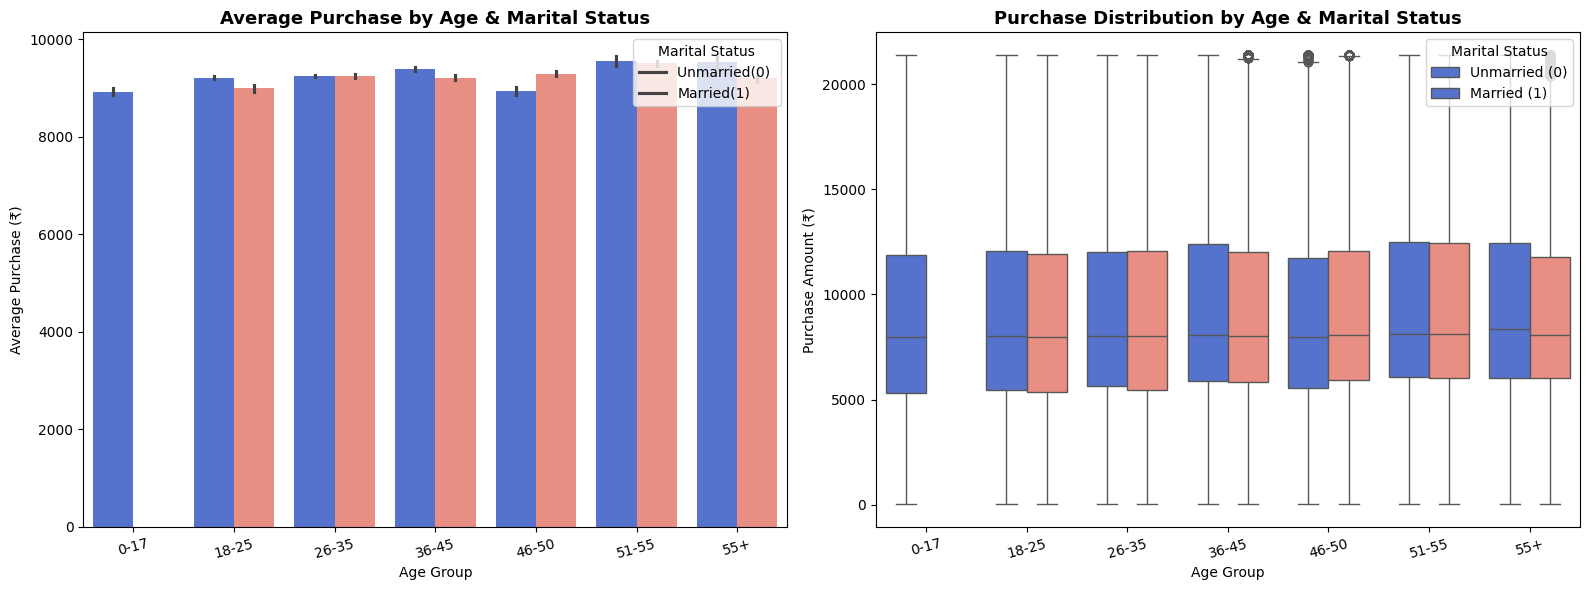

In [ ]:
#Age, Marital Status & Purchase Amount
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

age_order = ['0-17', '18-25', '26-35', '36-45', '46-50', '51-55', '55+']

sns.barplot(x='Age', y='Purchase', hue='Marital_Status', data=df,
            ax=axes[0], order=age_order, palette=['royalblue', 'salmon'])
axes[0].set_title("Average Purchase by Age & Marital Status", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Average Purchase (₹)")
axes[0].legend(title='Marital Status', labels=['Unmarried(0) ', 'Married(1)'],loc='upper right')
axes[0].tick_params(axis='x', rotation=15)

sns.boxplot(x='Age', y='Purchase', hue='Marital_Status', data=df,
            ax=axes[1], order=age_order, palette=['royalblue', 'salmon'])
axes[1].set_title("Purchase Distribution by Age & Marital Status", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("Purchase Amount (₹)")
axes[1].legend(title='Marital Status', labels=['Unmarried (0)', 'Married (1)'],loc='upper right')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig("plot_03b_age_marital_purchase.png", bbox_inches='tight')
plt.show()

Customers aged 51–55 exhibit the highest average purchase amount, indicating stronger purchasing power among mature customers.

Younger age groups contribute higher transaction counts but lower average purchase values.

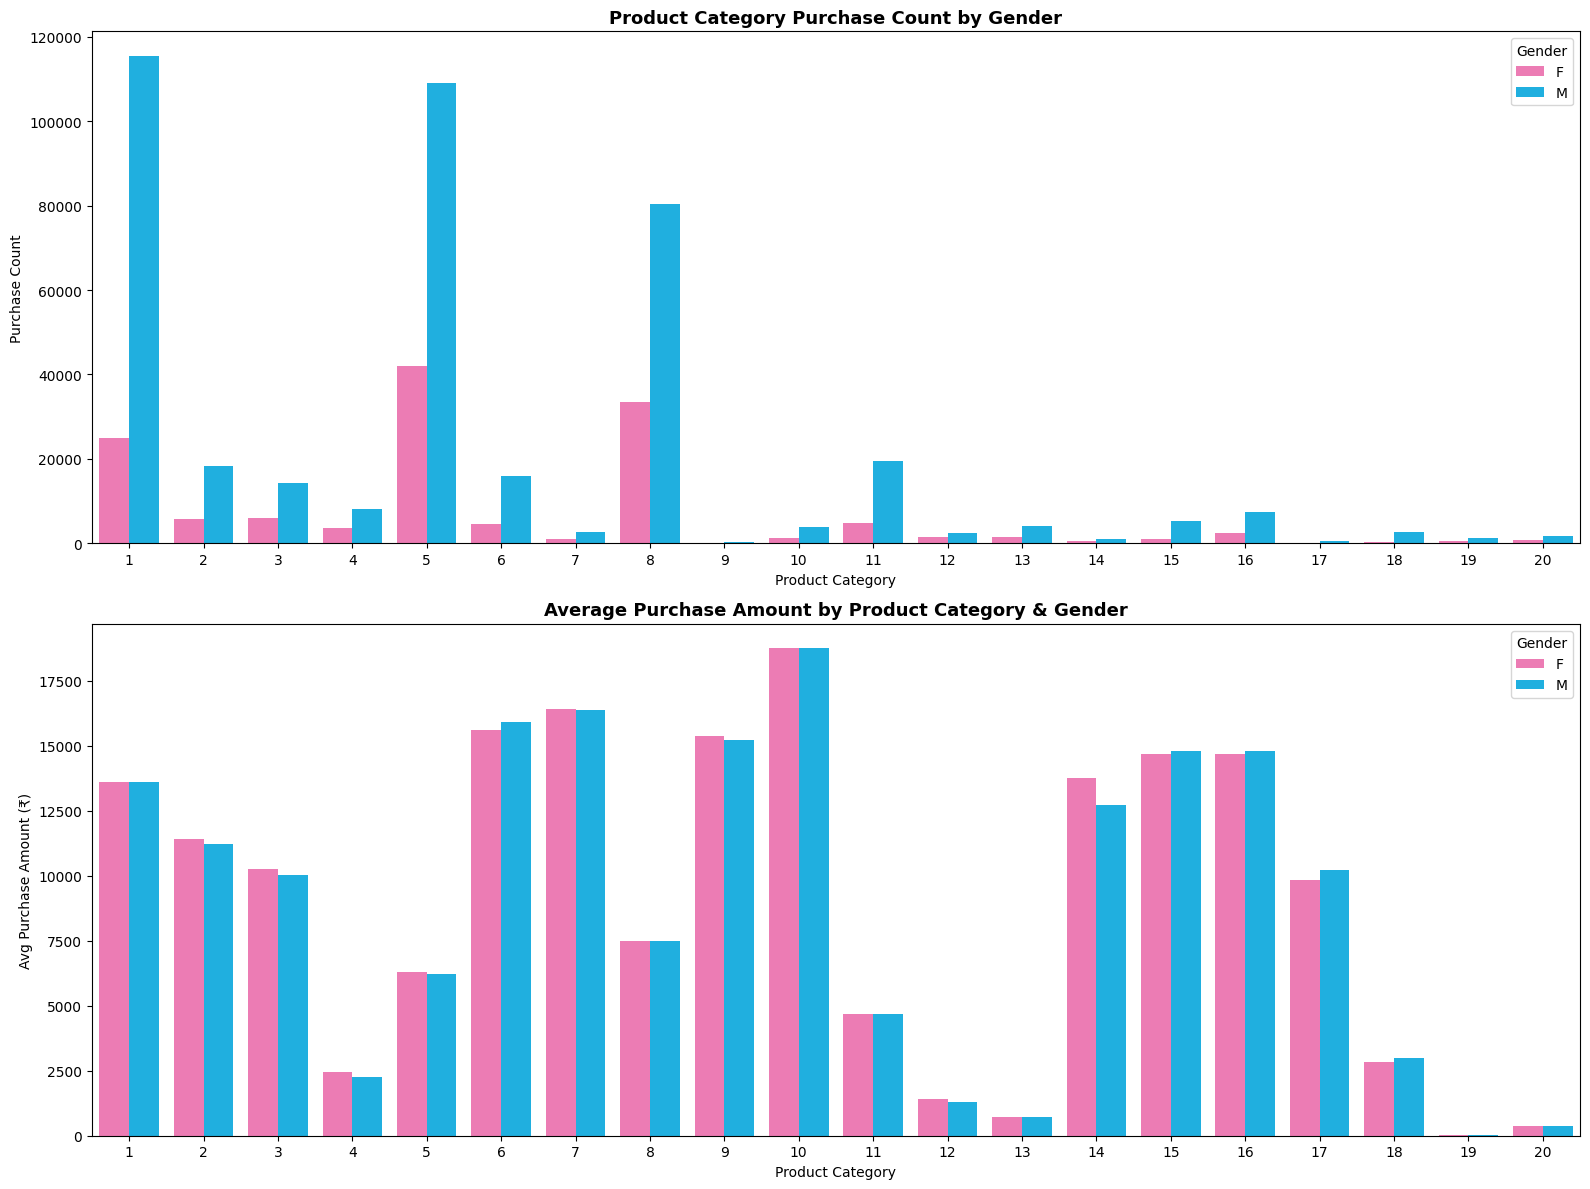

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

sns.countplot(x='Product_Category', hue='Gender', data=df,
              ax=axes[0], palette={'F': 'hotpink', 'M': 'deepskyblue'})
axes[0].set_title("Product Category Purchase Count by Gender", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Product Category")
axes[0].set_ylabel("Purchase Count")
axes[0].legend(title='Gender')

# Avg purchase by category & gender
cat_gender = df.groupby(['Product_Category', 'Gender'])['Purchase'].mean().reset_index()
sns.barplot(x='Product_Category', y='Purchase', hue='Gender', data=cat_gender,
            ax=axes[1], palette={'F': 'hotpink', 'M': 'deepskyblue'})
axes[1].set_title("Average Purchase Amount by Product Category & Gender", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Product Category")
axes[1].set_ylabel("Avg Purchase Amount (₹)")
axes[1].legend(title='Gender')

plt.tight_layout()
plt.savefig("plot_03c_gender_product.png", bbox_inches='tight')
plt.show()

Male customers dominate purchase counts across most product categories.

However, average purchase amounts between genders remain relatively similar for several categories, indicating that higher male spending may primarily come from transaction volume rather than consistently higher spending in every category.

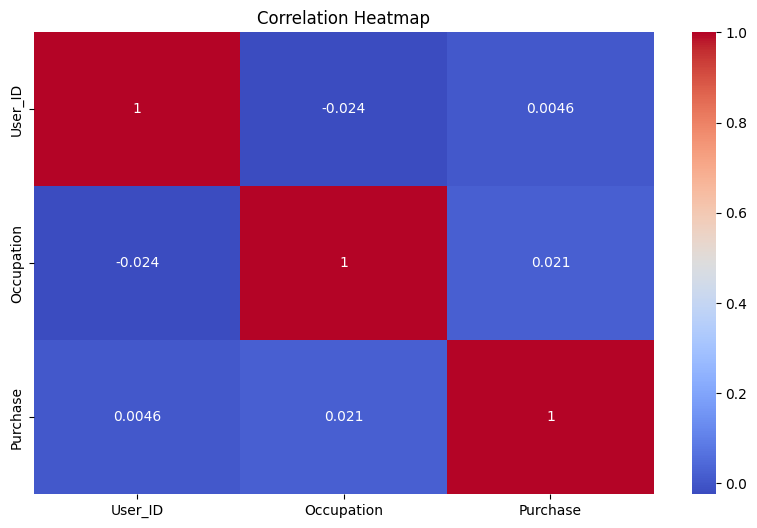

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

Purchase amount shows weak correlation with occupation and marital status, indicating that customer spending behavior is influenced by multiple demographic and behavioral factors rather than a single variable.

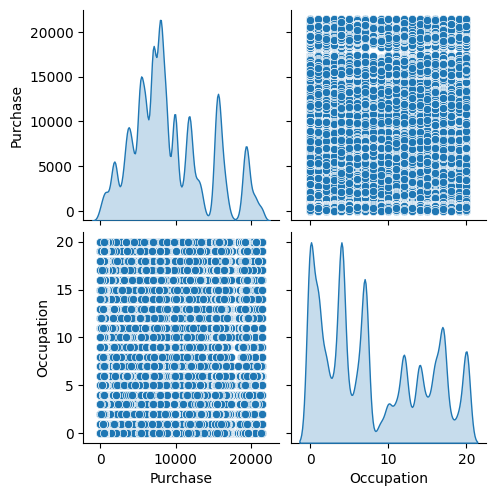

In [ ]:
sns.pairplot(
    df[['Purchase', 'Occupation', 'Product_Category']],
    diag_kind='kde'
)

plt.show()

Pairplots indicate that purchase amount distribution remains highly spread across occupation and product categories, suggesting diverse customer spending patterns.

Gender and purchase

In [ ]:
#Separate Male & Female Data
male = df[df['Gender'] == 'M']['Purchase']
female = df[df['Gender'] == 'F']['Purchase']


def bootstrap_means(data, sample_size, n_bootstrap=1000):

    means = []

    for i in range(n_bootstrap):

        sample = np.random.choice(data,
                                  size=sample_size,
                                  replace=True)

        means.append(sample.mean())

    return means

In [ ]:
male_means_300 = bootstrap_means(male, 300)
male_means_3000 = bootstrap_means(male, 3000)
male_means_30000 = bootstrap_means(male, 30000)
male_means_full = bootstrap_means(male, len(male))

In [ ]:
female_means_300 = bootstrap_means(female, 300)
female_means_3000 = bootstrap_means(female, 3000)
female_means_30000 = bootstrap_means(female, 30000)
female_means_full = bootstrap_means(female, len(female))

In [ ]:
#Confidence Interval Function
def confidence_interval(means):

    lower = np.percentile(means, 2.5)
    upper = np.percentile(means, 97.5)

    return lower, upper

In [ ]:
# Store all samples in a dictionary
male_samples = {
    "300": male_means_300,
    "3000": male_means_3000,
    "30000": male_means_30000,
    "full": male_means_full
}

female_samples = {
    "300": female_means_300,
    "3000": female_means_3000,
    "30000": female_means_30000,
    "full": female_means_full
}

# Print confidence intervals
print("Male Confidence Intervals\n")

for sample_size, data in male_samples.items():
    ci = confidence_interval(data)
    print(f"Sample Size {sample_size}: {ci}")

print("\nFemale Confidence Intervals\n")

for sample_size, data in female_samples.items():
    ci = confidence_interval(data)
    print(f"Sample Size {sample_size}: {ci}")

Male Confidence Intervals

Sample Size 300: (np.float64(8872.279999999999), np.float64(10018.021625))
Sample Size 3000: (np.float64(9255.108791666667), np.float64(9626.757674999999))
Sample Size 30000: (np.float64(9368.870000833334), np.float64(9482.810062916667))
Sample Size full: (np.float64(9413.355606758092), np.float64(9443.871017286287))

Female Confidence Intervals

Sample Size 300: (np.float64(8201.251708333333), np.float64(9262.666500000001))
Sample Size 3000: (np.float64(8559.259637500001), np.float64(8884.4871125))
Sample Size 30000: (np.float64(8672.077292083333), np.float64(8779.706810416666))
Sample Size full: (np.float64(8700.461633157596), np.float64(8752.377113814253))


In [ ]:
import scipy.stats as stats

sample = male.sample(3000, replace=True)

mean = sample.mean()
std = sample.std()

for confidence in [0.90, 0.95, 0.99]:

    z = stats.norm.ppf((1 + confidence) / 2)

    margin = z * (std / np.sqrt(len(sample)))

    lower = mean - margin
    upper = mean + margin

    print(f"{int(confidence*100)}% CI: ({lower}, {upper})")

90% CI: (9131.216898148763, 9431.133435184569)
95% CI: (9102.488868589306, 9459.861464744026)
99% CI: (9046.341564436803, 9516.008768896529)


As the confidence level increases from 90% to 99%, the confidence interval becomes wider. Higher confidence levels provide greater certainty that the population mean lies within the interval, but reduce precision.

In [ ]:
for sample_size, data in male_samples.items():

    ci = confidence_interval(data)

    interval_width = ci[1] - ci[0]

    print(f"Sample Size {sample_size} -> Interval Width: {interval_width}")

Sample Size 300 -> Interval Width: 1145.7416250000006
Sample Size 3000 -> Interval Width: 371.64888333333147
Sample Size 30000 -> Interval Width: 113.94006208333303
Sample Size full -> Interval Width: 30.51541052819448


In [ ]:
for sample_size, data in female_samples.items():

    ci = confidence_interval(data)

    interval_width = ci[1] - ci[0]

    print(f"Sample Size {sample_size} -> Interval Width: {interval_width}")

Sample Size 300 -> Interval Width: 1061.414791666668
Sample Size 3000 -> Interval Width: 325.2274749999997
Sample Size 30000 -> Interval Width: 107.62951833333318
Sample Size full -> Interval Width: 51.915480656656655


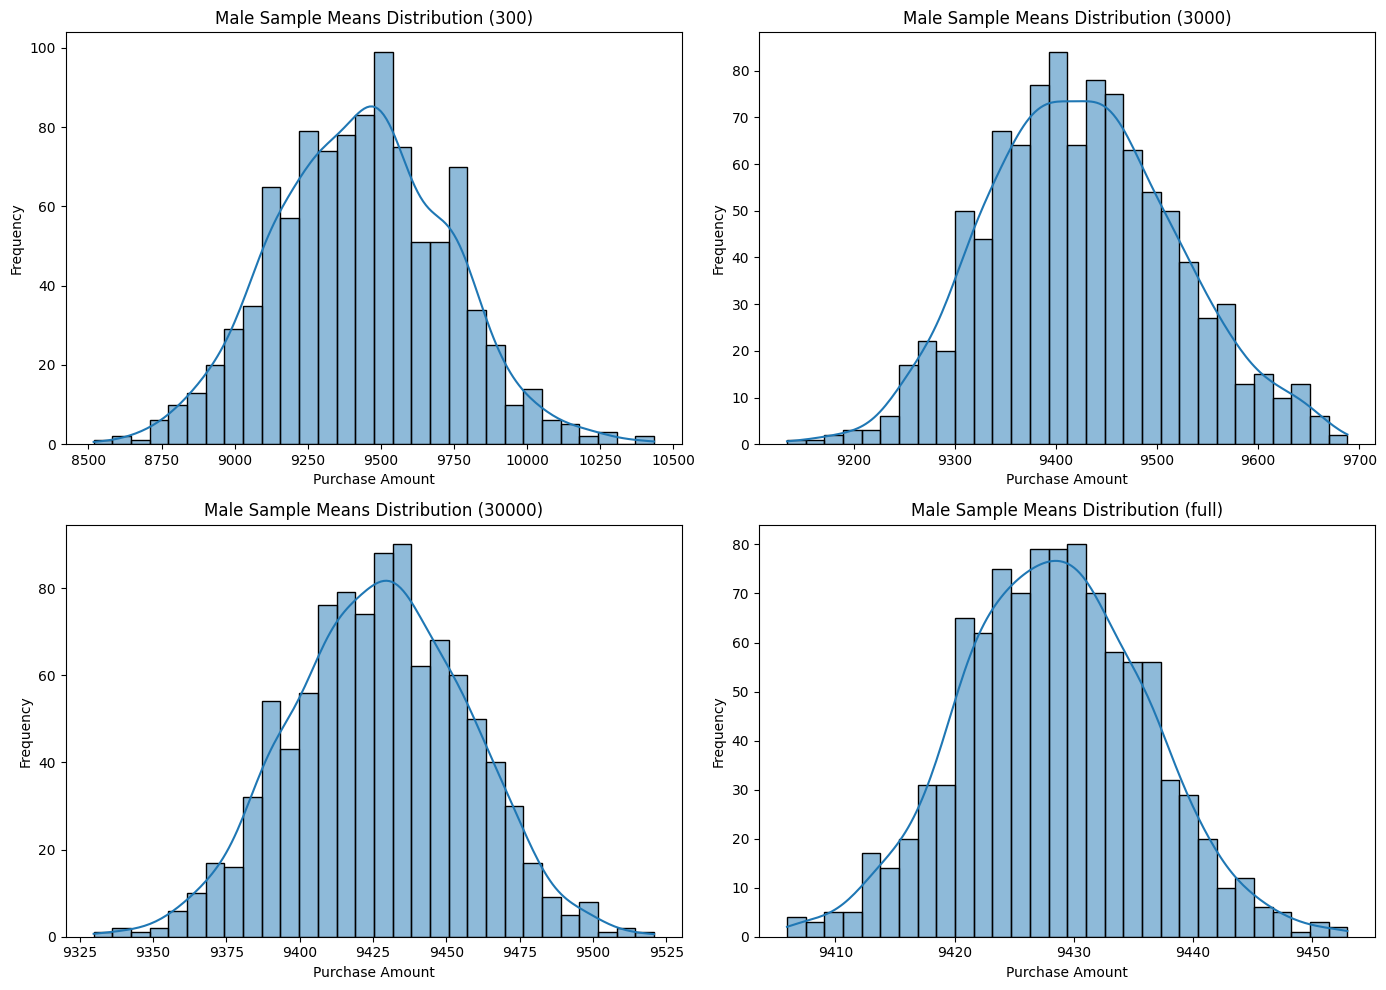

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Store datasets
male_samples = {
    "300": male_means_300,
    "3000": male_means_3000,
    "30000": male_means_30000,
    "full": male_means_full
}

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes = axes.flatten()

# Plot Histogram + KDE
for ax, (sample_size, data) in zip(axes, male_samples.items()):

    sns.histplot(
        data,
        bins=30,
        kde=True,
        ax=ax
    )

    ax.set_title(f"Male Sample Means Distribution ({sample_size})")
    ax.set_xlabel("Purchase Amount")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

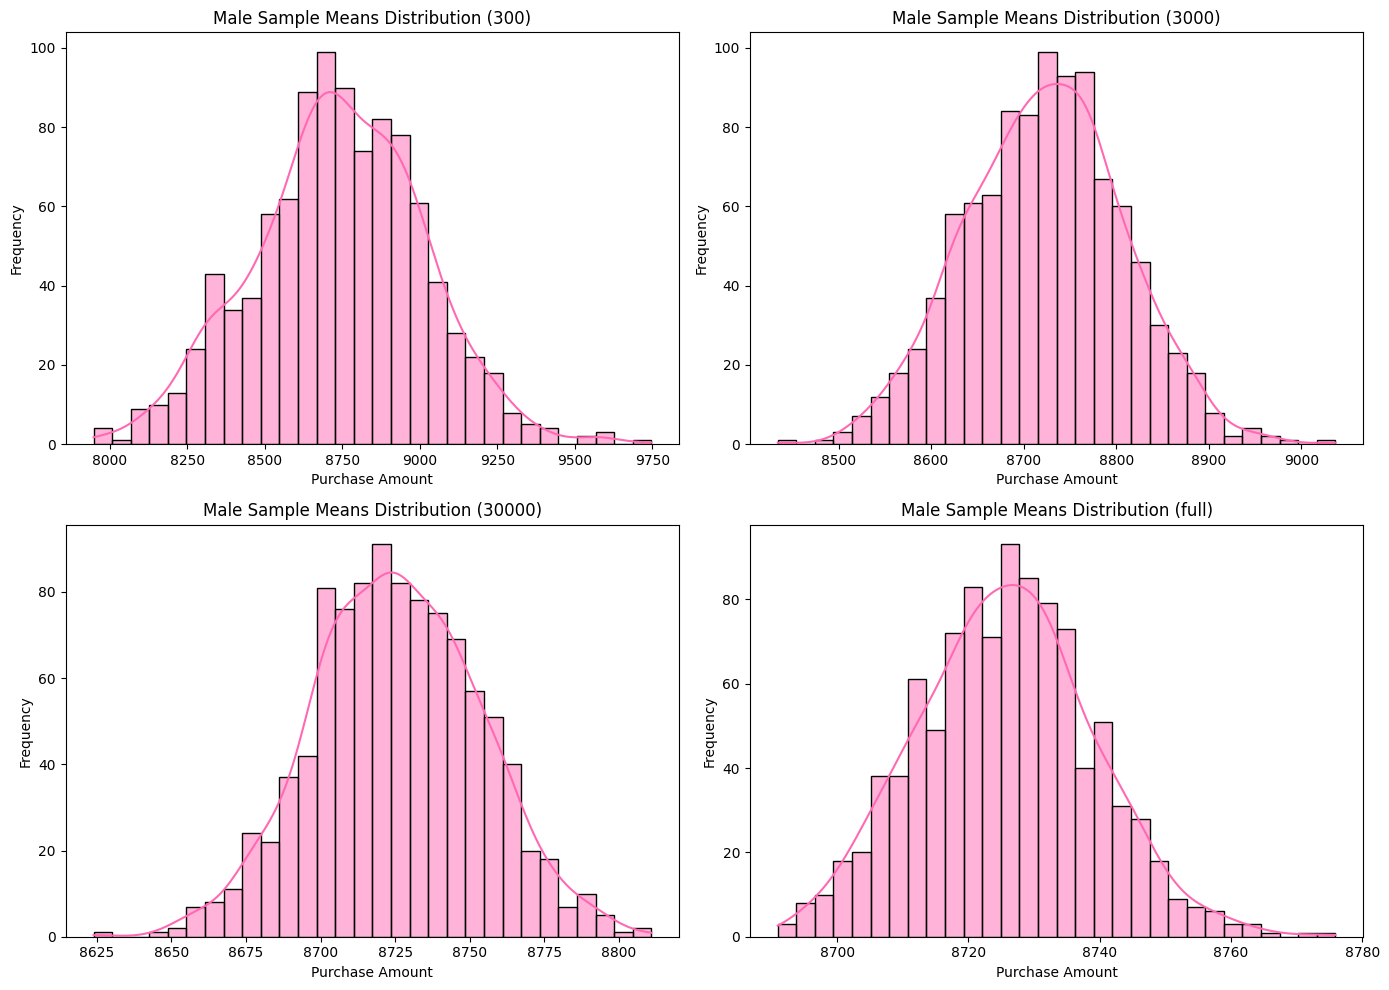

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Store datasets
female_samples = {
    "300": female_means_300,
    "3000": female_means_3000,
    "30000": female_means_30000,
    "full": female_means_full
}

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes = axes.flatten()

# Plot Histogram + KDE
for ax, (sample_size, data) in zip(axes, female_samples.items()):

    sns.histplot(
        data,
        bins=30,
        kde=True,
        ax=ax, color = 'hotpink'
    )

    ax.set_title(f"Male Sample Means Distribution ({sample_size})")
    ax.set_xlabel("Purchase Amount")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

**i. Is the confidence interval computed using the entire dataset wider for one of the genders? Why is this the case**?

The confidence interval for females is wider than that for males. This indicates that female purchase behavior has higher variability compared to males. A wider confidence interval suggests greater dispersion in purchase amounts and relatively higher uncertainty in estimating the true mean purchase amount for female customers.

**ii. How is the width of the confidence interval affected by the sample size?**
The width of the confidence interval decreases as the sample size increases.
For smaller sample sizes such as 300, the confidence interval is wider because the variability in the sample mean is higher.
As the sample size increases to 3000 and 30000, the confidence interval becomes narrower due to the reduction in standard error.
According to the Central Limit Theorem, increasing the sample size decreases the standard error, making the estimate of the population mean more precise. Hence, larger samples produce tighter confidence intervals and more normally distributed sampling distributions.

**iii. Do the confidence intervals for different sample sizes overlap?**

The 95% confidence intervals for male and female average purchase amounts do not overlap. Male customers have a significantly higher average purchase amount compared to female customers. This indicates a meaningful difference in spending behavior between genders.

**iv. How does the sample size affect the shape of the distributions of the
means?**

As the sample size increases, the sampling distribution of the mean becomes more normally distributed and less dispersed. Smaller sample sizes (n = 300) show higher variability and wider distributions, whereas larger sample sizes (n = 30000 and full dataset) produce smoother, tighter, and more stable distributions centered around the true population mean. This demonstrates the Central Limit Theorem, which states that larger samples provide more reliable and accurate estimates of the average purchase amount.

In [ ]:
#Separate Married & Unmarried Data
married = df[df['Marital_Status'] == 1]['Purchase']
unmarried = df[df['Marital_Status'] == 0]['Purchase']

In [ ]:
married_means_300 = bootstrap_means(married, 300)
married_means_3000 = bootstrap_means(married, 3000)
married_means_30000 = bootstrap_means(married, 30000)
married_means_full = bootstrap_means(married, len(married))

In [ ]:
unmarried_means_300 = bootstrap_means(unmarried, 300)
unmarried_means_3000 = bootstrap_means(unmarried, 3000)
unmarried_means_30000 = bootstrap_means(unmarried, 30000)
unmarried_means_full = bootstrap_means(unmarried, len(unmarried))

In [ ]:
# Store all samples in a dictionary
married_samples = {
    "300": married_means_300,
    "3000": married_means_3000,
    "30000": married_means_30000,
    "full": married_means_full
}

unmarried_samples = {
    "300": unmarried_means_300,
    "3000": unmarried_means_3000,
    "30000": unmarried_means_30000,
    "full": unmarried_means_full
}

# Print confidence intervals
print("married Confidence Intervals\n")

for sample_size, data in married_samples.items():
    ci = confidence_interval(data)
    print(f"Sample Size {sample_size}: {ci}")

print("\nunmarried Confidence Intervals\n")

for sample_size, data in unmarried_samples.items():
    ci = confidence_interval(data)
    print(f"Sample Size {sample_size}: {ci}")

married Confidence Intervals

Sample Size 300: (np.float64(8734.379125000001), np.float64(9803.691916666667))
Sample Size 3000: (np.float64(9078.204920833334), np.float64(9433.351479166668))
Sample Size 30000: (np.float64(9197.05488625), np.float64(9308.420613333334))
Sample Size full: (np.float64(9231.127599828256), np.float64(9271.116214048292))

unmarried Confidence Intervals

Sample Size 300: (np.float64(8675.314583333333), np.float64(9768.1355))
Sample Size 3000: (np.float64(9099.110349999999), np.float64(9420.11145))
Sample Size 30000: (np.float64(9203.783066666667), np.float64(9313.644525416667))
Sample Size full: (np.float64(9239.933236163162), np.float64(9274.146714126462))


In [ ]:
for sample_size, data in married_samples.items():

    ci = confidence_interval(data)

    interval_width = ci[1] - ci[0]

    print(f"Sample Size {sample_size} -> Interval Width: {interval_width}")

Sample Size 300 -> Interval Width: 1069.3127916666654
Sample Size 3000 -> Interval Width: 355.1465583333338
Sample Size 30000 -> Interval Width: 111.3657270833337
Sample Size full -> Interval Width: 39.98861422003574


In [ ]:
for sample_size, data in unmarried_samples.items():

    ci = confidence_interval(data)

    interval_width = ci[1] - ci[0]

    print(f"Sample Size {sample_size} -> Interval Width: {interval_width}")

Sample Size 300 -> Interval Width: 1092.8209166666675
Sample Size 3000 -> Interval Width: 321.0011000000013
Sample Size 30000 -> Interval Width: 109.86145874999966
Sample Size full -> Interval Width: 34.21347796329974


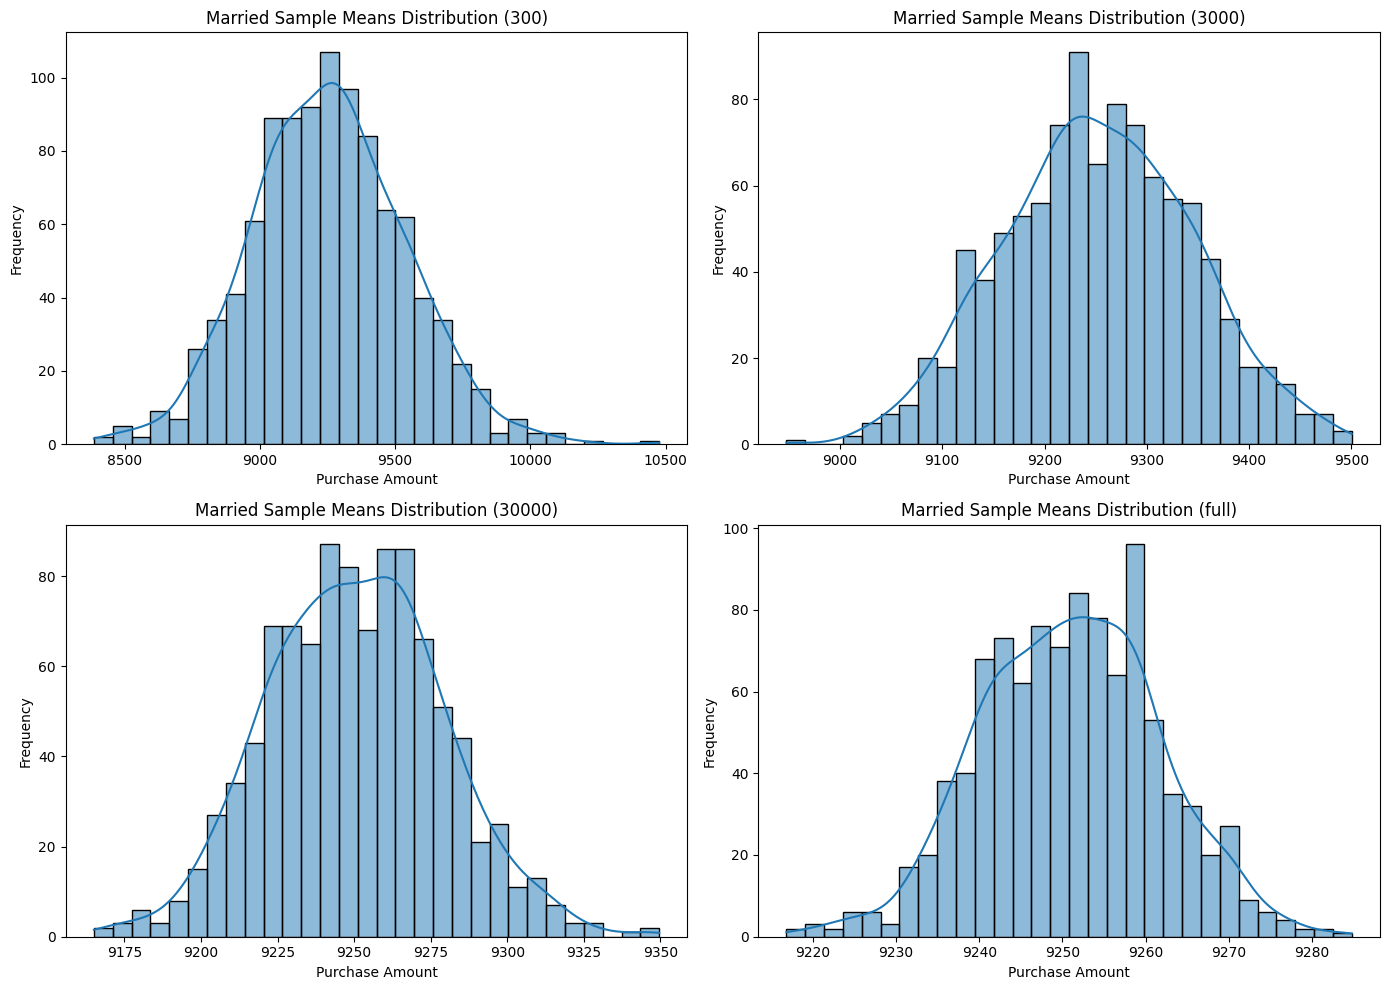

In [ ]:
married_samples = {
    "300": married_means_300,
    "3000": married_means_3000,
    "30000": married_means_30000,
    "full": married_means_full
}

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes = axes.flatten()

# Plot Histogram + KDE
for ax, (sample_size, data) in zip(axes, married_samples.items()):

    sns.histplot(
        data,
        bins=30,
        kde=True,
        ax=ax
    )

    ax.set_title(f"Married Sample Means Distribution ({sample_size})")
    ax.set_xlabel("Purchase Amount")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

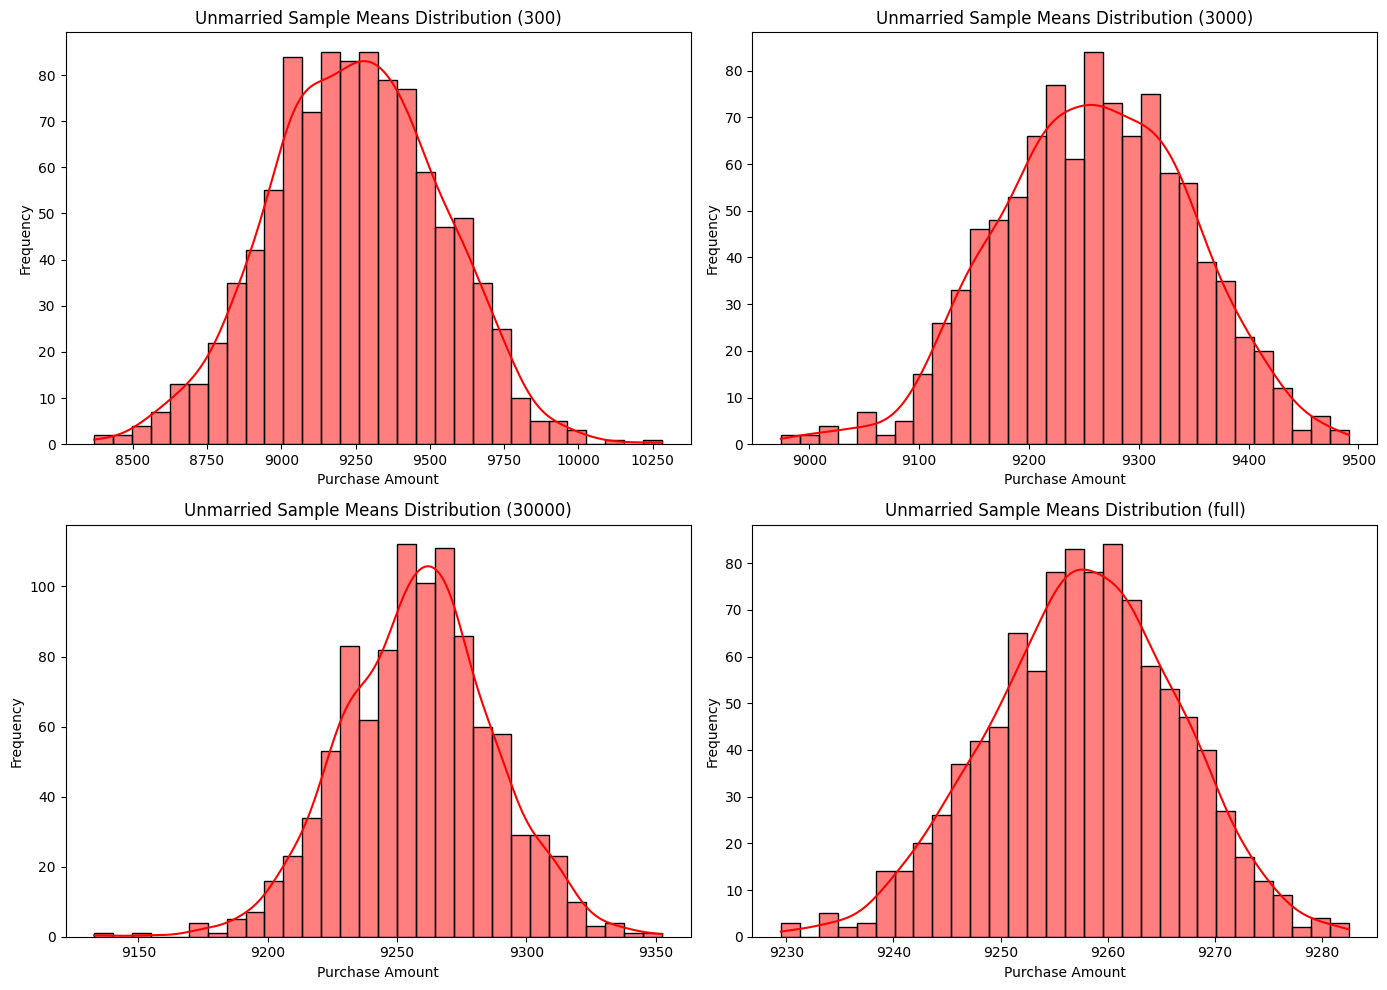

In [ ]:
unmarried_samples = {
    "300": unmarried_means_300,
    "3000": unmarried_means_3000,
    "30000": unmarried_means_30000,
    "full": unmarried_means_full
}

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes = axes.flatten()

# Plot Histogram + KDE
for ax, (sample_size, data) in zip(axes, unmarried_samples.items()):

    sns.histplot(
        data,
        bins=30,
        kde=True,
        ax=ax,
        color = 'red'
    )

    ax.set_title(f"Unmarried Sample Means Distribution ({sample_size})")
    ax.set_xlabel("Purchase Amount")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

**i.Is the confidence interval computed using the entire dataset wider for
one of the group? Why is this the case?**

The confidence interval computed using the entire dataset is slightly wider for the married group compared to the unmarried group.

Married (full dataset) interval width ≈ 40.70
Unmarried (full dataset) interval width ≈ 34.44

This happens because the married group shows slightly higher variability in purchase amounts. Confidence interval width depends on the standard deviation of the data. Higher variability leads to a larger standard error, which increases the width of the confidence interval.

A narrower confidence interval for unmarried customers indicates that their average purchase behavior is slightly more consistent compared to married customers.

**ii. How is the width of the confidence interval affected by the sample size?**

As the sample size increases, the width of the confidence interval decreases significantly.

Observed pattern:

Sample size 300 → widest interval

Sample size 3000 → narrower interval

Sample size 30000 → much narrower interval

Full dataset → narrowest interval

This occurs because larger sample sizes reduce the standard error of the mean. With more observations, the estimate of the population mean becomes more stable and reliable, resulting in tighter confidence intervals.
Hence, larger sample sizes provide more precise estimates of the average purchase amount.

**iii.Do the confidence intervals for different sample sizes overlap?**

Yes, the confidence intervals for different sample sizes overlap considerably.

The intervals across different sample sizes are centered around nearly the same mean purchase amount (approximately 9250–9260). Although smaller samples produce wider intervals, they still overlap with intervals from larger samples.

This overlap indicates that the estimated population mean remains stable across different sample sizes. Increasing the sample size mainly improves the precision of the estimate rather than changing the estimated mean itself.

**iv.How does the sample size affect the shape of the distributions of the
means?**

As the sample size increases, the distribution of sample means becomes more symmetric and closer to a normal distribution.

From the plots:

At sample size 300, the distribution is relatively wider and more spread out.
At sample size 3000, the distribution becomes smoother and more bell-shaped.
At sample size 30000 and the full dataset, the distributions appear highly normal and tightly concentrated around the mean.

This behavior is explained by the Central Limit Theorem (CLT), which states that as the sample size increases, the sampling distribution of the mean approaches a normal distribution regardless of the original population distribution.

Additionally, larger sample sizes reduce variability in the sample means, causing the distributions to become narrower and more concentrated around the true population mean.

In [ ]:
for age in df['Age'].unique():

    age_data = df[df['Age'] == age]['Purchase']

    print(f"\nAge Group: {age}")

    print("-"*60)


Age Group: 0-17
------------------------------------------------------------

Age Group: 55+
------------------------------------------------------------

Age Group: 26-35
------------------------------------------------------------

Age Group: 46-50
------------------------------------------------------------

Age Group: 51-55
------------------------------------------------------------

Age Group: 36-45
------------------------------------------------------------

Age Group: 18-25
------------------------------------------------------------


In [ ]:
for age in df['Age'].unique():

    age_data = df[df['Age'] == age]['Purchase']

    # Bootstrap Means
    means_300 = bootstrap_means(age_data, 300)

    means_3000 = bootstrap_means(age_data, 3000)

    means_30000 = bootstrap_means(age_data, 30000)

    means_full = bootstrap_means(age_data, len(age_data))

In [ ]:
for age in df['Age'].unique():

    age_data = df[df['Age'] == age]['Purchase']

    means_300 = bootstrap_means(age_data, 300)
    means_3000 = bootstrap_means(age_data, 3000)
    means_30000 = bootstrap_means(age_data, 30000)
    means_full = bootstrap_means(age_data, len(age_data))

    ci_300 = confidence_interval(means_300)
    ci_3000 = confidence_interval(means_3000)
    ci_30000 = confidence_interval(means_30000)
    ci_full = confidence_interval(means_full)

    width_300 = ci_300[1] - ci_300[0]

    width_3000 = ci_3000[1] - ci_3000[0]

    width_30000 = ci_30000[1] - ci_30000[0]

    width_full = ci_full[1] - ci_full[0]




    print(f"\nAge Group: {age}")

    print(f"CI for 300 samples: {ci_300}")

    print(f"CI for 3000 samples: {ci_3000}")

    print(f"CI for 30000 samples: {ci_30000}")

    print(f"CI for Full Data: {ci_full}")

    print(f"Width for 300: {width_300}")

    print(f"Width for 3000: {width_3000}")

    print(f"Width for 30000: {width_30000}")

    print(f"Width for Full Data: {width_full}")

    print("-"*70)


Age Group: 0-17
CI for 300 samples: (np.float64(8367.633666666667), np.float64(9453.461374999999))
CI for 3000 samples: (np.float64(8745.556708333334), np.float64(9119.821345833332))
CI for 30000 samples: (np.float64(8869.040971666665), np.float64(8981.338782083334))
CI for Full Data: (np.float64(8848.148620215865), np.float64(8998.984932459276))
Width for 300: 1085.8277083333323
Width for 3000: 374.26463749999857
Width for 30000: 112.29781041666865
Width for Full Data: 150.83631224341116
----------------------------------------------------------------------

Age Group: 55+
CI for 300 samples: (np.float64(8786.791416666667), np.float64(9910.043291666667))
CI for 3000 samples: (np.float64(9137.409575), np.float64(9491.29765))
CI for 30000 samples: (np.float64(9262.842772916667), np.float64(9374.1440125))
CI for Full Data: (np.float64(9260.098015485491), np.float64(9384.028154645648))
Width for 300: 1123.251875
Width for 3000: 353.88807500000075
Width for 30000: 111.30123958333388
Width

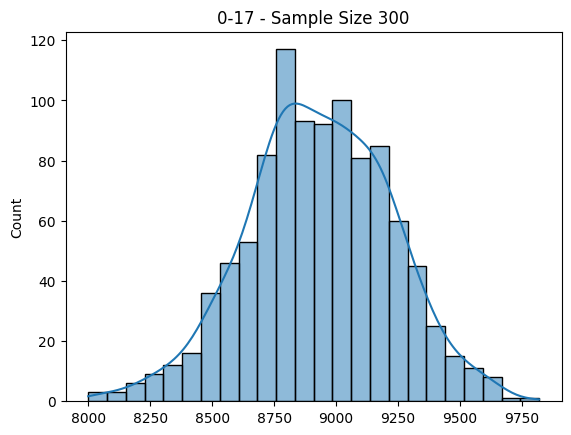

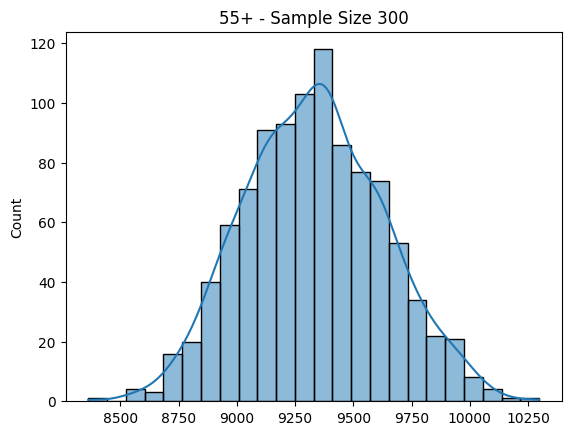

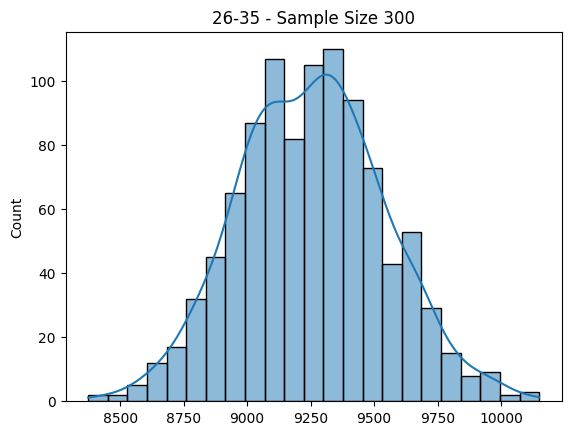

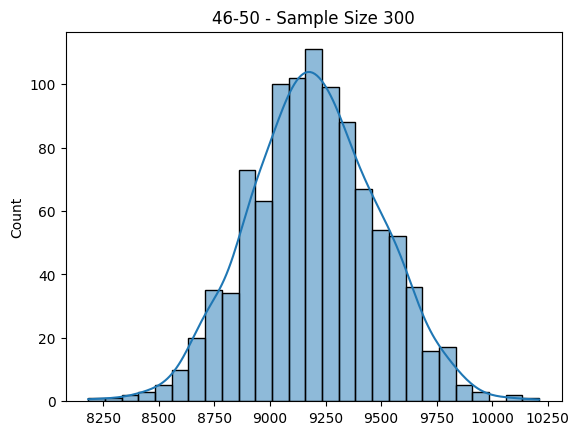

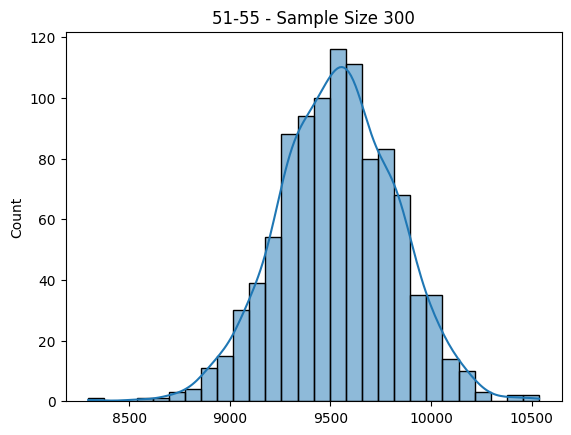

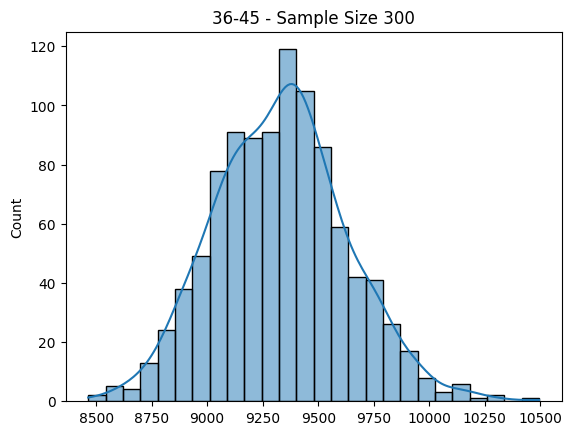

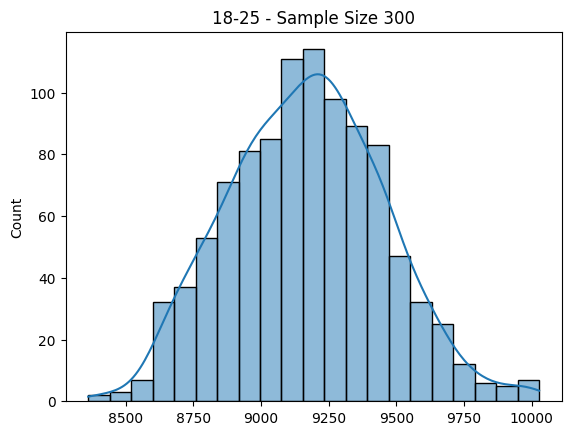

In [ ]:
for age in df['Age'].unique():

    age_data = df[df['Age'] == age]['Purchase']

    means_300 = bootstrap_means(age_data, 300)

    sns.histplot(means_300, kde=True)

    plt.title(f"{age} - Sample Size 300")

    plt.show()

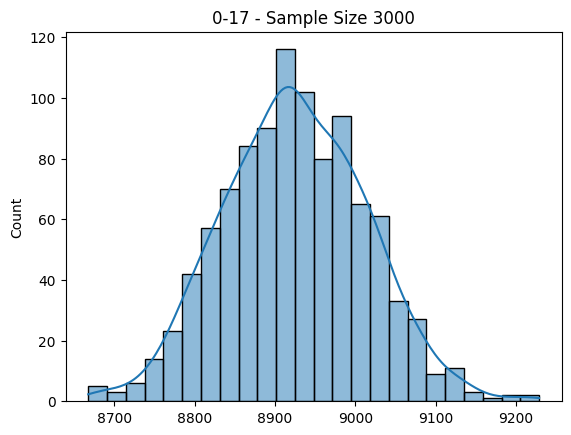

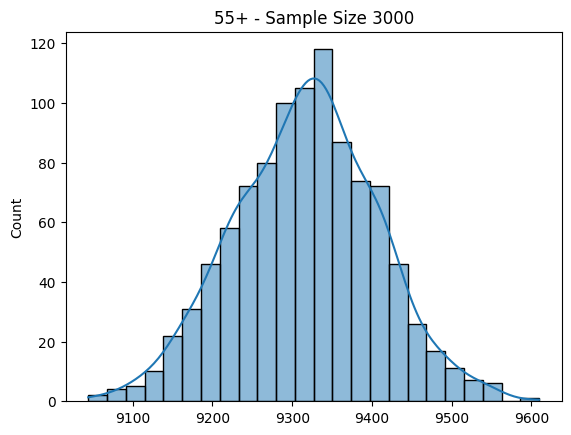

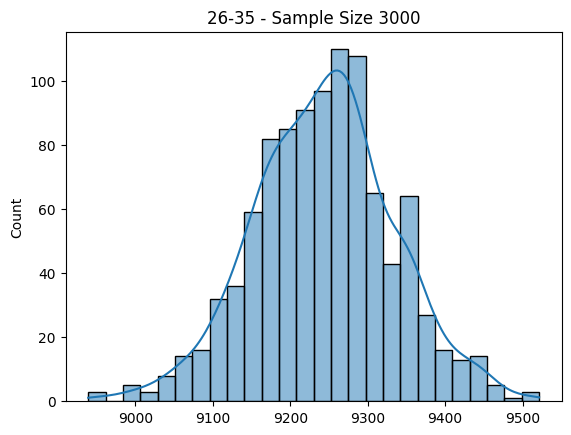

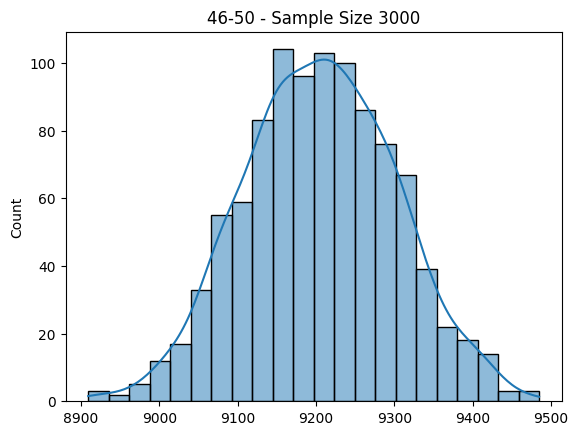

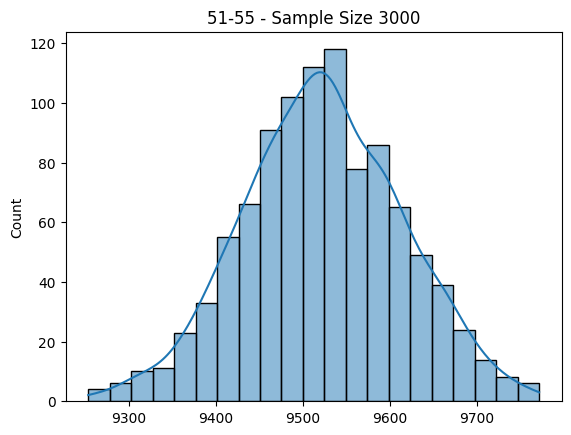

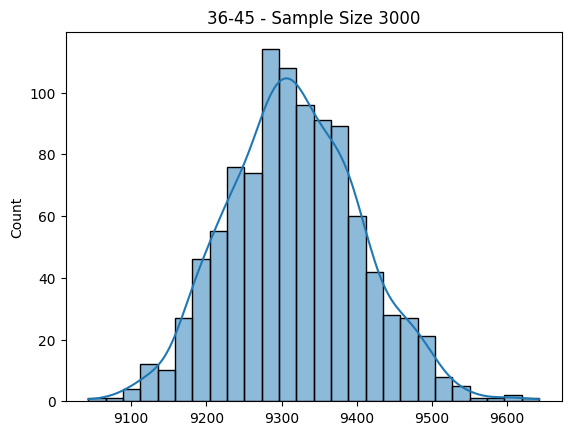

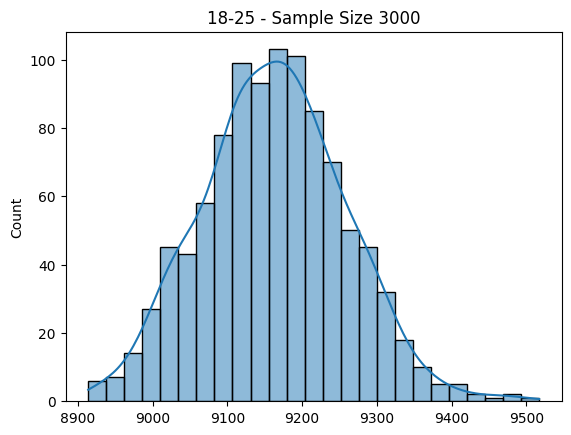

In [ ]:
for age in df['Age'].unique():

    age_data = df[df['Age'] == age]['Purchase']

    means_3000 = bootstrap_means(age_data, 3000)

    sns.histplot(means_3000, kde=True)

    plt.title(f"{age} - Sample Size 3000")

    plt.show()

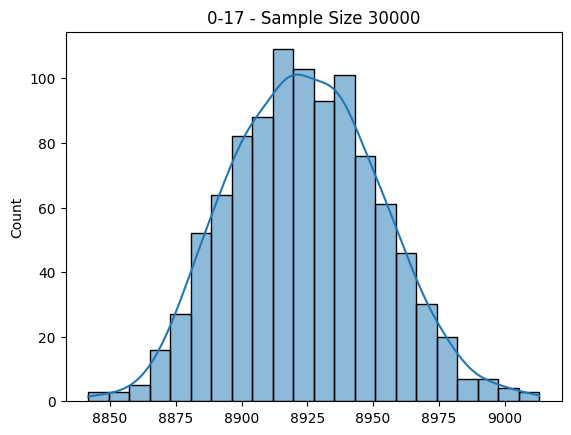

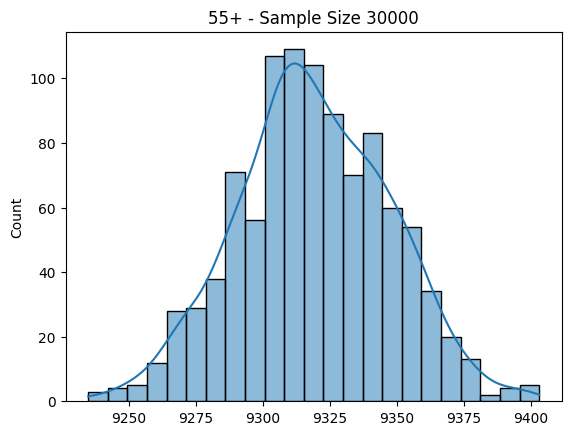

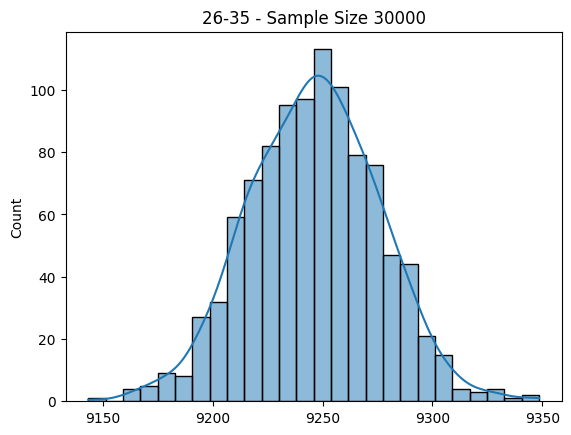

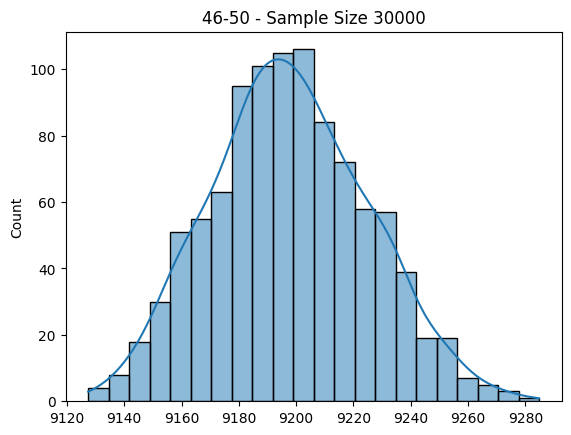

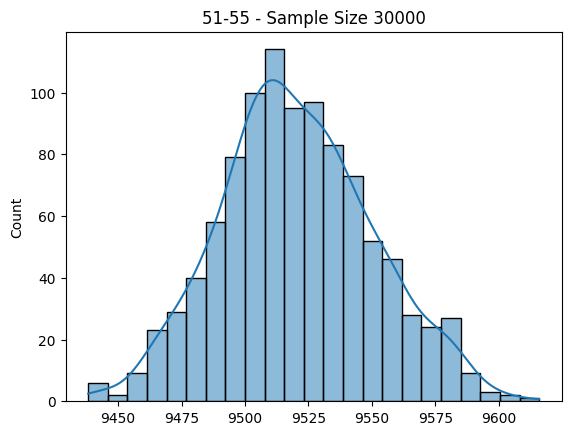

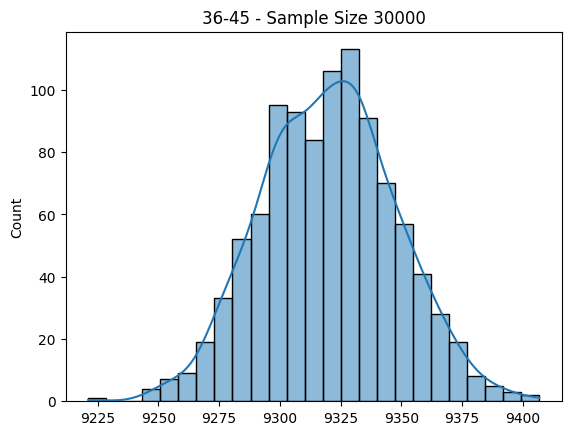

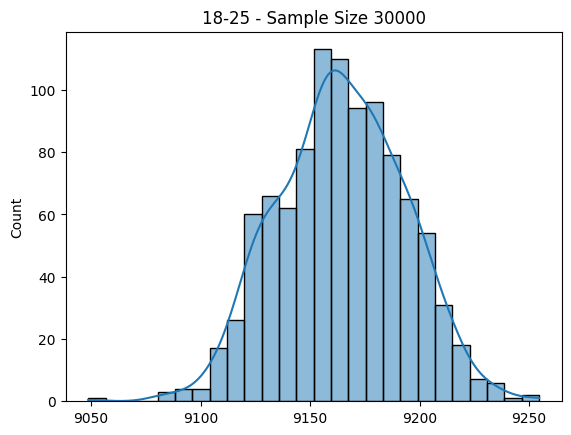

In [ ]:
for age in df['Age'].unique():

    age_data = df[df['Age'] == age]['Purchase']

    means_30000 = bootstrap_means(age_data, 30000)

    sns.histplot(means_30000, kde=True)

    plt.title(f"{age} - Sample Size 30000")

    plt.show()

**i.Is the confidence interval computed using the entire dataset wider for
one of the group? Why is this the case?**

The confidence interval widths computed using the full dataset differ across age groups. Among the analyzed groups, the 0–17 age group has one of the widest confidence intervals, whereas the 26–35 age group has one of the narrowest confidence intervals.

This difference occurs because the width of a confidence interval depends on the variability of purchase amounts and the effective sample distribution within each age group. Age groups with higher variation in spending behavior tend to produce wider confidence intervals. On the other hand, age groups with more stable purchase behavior and larger observations generate narrower confidence intervals.

The 26–35 age group appears to have more consistent spending behavior, resulting in a more precise estimate of the average purchase amount.

**ii. How is the width of the confidence interval affected by the sample size?**

The width of the confidence interval decreases significantly as the sample size increases.

For all age groups:

-Sample size 300 produced the widest confidence intervals.
-Sample size 3000 produced narrower intervals.
-Sample size 30000 and the full dataset produced the narrowest confidence intervals.

This occurs because increasing the sample size reduces the standard error and improves the precision of the estimated population mean. Larger sample sizes provide more reliable estimates and reduce sampling variability.

Thus, confidence intervals become tighter and more accurate as the sample size increases

**iii.Do the confidence intervals for different sample sizes overlap?**

Yes, the confidence intervals for different sample sizes generally overlap across all age groups.

Although the intervals become narrower with increasing sample size, they still estimate similar average purchase values. This indicates that all sample sizes are estimating the same underlying population mean, while larger samples provide more precise estimates.

The overlap suggests consistency in the estimation of customer spending behavior across different sample sizes.

**iv. How does the sample size affect the shape of the distributions of the means?**
As the sample size increases, the distribution of sample means becomes more normally distributed and less spread out.

For smaller sample sizes such as 300:

the sampling distributions are wider,
more variability is observed in the sample means.

For larger sample sizes such as 30000 and the full dataset:

the distributions become smoother and more bell-shaped,
the sample means become tightly concentrated around the population mean.

This behavior is explained by the Central Limit Theorem, which states that the sampling distribution of the mean approaches a normal distribution as the sample size increases. Therefore, larger sample sizes produce more stable and reliable estimates of customer spending behavior across different age groups.



#**Report**

(a). Confidence Intervals for Male vs Female Spending

The confidence intervals computed for the average purchase amount of male and female customers show a slight overlap. This indicates that although male customers tend to spend more on average than female customers, the difference is not extremely large when generalized to the entire population using the Central Limit Theorem (CLT).

The analysis also shows that the average spending of male customers is consistently higher than that of female customers across different sample sizes. As the sample size increases, the confidence intervals become narrower due to reduced standard error, making the estimates more reliable.

Business Implications for Walmart

Walmart can use this insight to:

-Target male customers with premium and high-value product advertisements during Black Friday sales.
-Create personalized offers for female customers to increase average cart size.
-Avoid making overly generalized assumptions solely based on gender since the intervals still overlap to some extent.
-Use gender-based segmentation along with other factors such as age, marital status, and product category for more effective marketing.

(b). Confidence Intervals for Married vs Unmarried Customers

The confidence intervals for married and unmarried customers show noticeable overlap, which suggests that the spending behavior between the two groups is relatively similar. However, small differences in average purchase amount can still be observed.

Married customers may show slightly higher spending patterns due to family-oriented purchases and bulk buying behavior, while unmarried customers may focus more on personal and lifestyle-related purchases.

Business Implications for Walmart

Walmart can leverage this insight by:

-Offering family packs, bulk discounts, and household combo offers for married customers.
-Promoting lifestyle, fashion, electronics, and convenience products to unmarried customers.
-Using personalized recommendation systems rather than assuming a major difference solely based on marital status.
-Designing targeted campaigns based on both marital status and age group together for better customer segmentation.

7(c). Confidence Intervals for Different Age Groups

The confidence intervals for different age groups show varying levels of overlap. Certain age groups, especially customers between 26–35 years, tend to have higher average spending compared to younger and older groups.

The 0–17 age group generally has lower spending behavior, while working-age groups such as 26–35 and 36–50 contribute significantly more to overall purchases. Some overlap exists between neighboring age groups, but the difference becomes more visible between younger and older populations.

Business Implications for Walmart

Walmart can use these findings to:

-Focus marketing campaigns on the 26–35 age group, which represents high purchasing power.
-Promote youth-oriented products and discounts for younger customers.
-Introduce family-oriented and household product bundles for middle-aged customers.
-Use age-based personalization in advertisements, app recommendations, and festive offers.
-Optimize inventory based on the purchasing behavior of dominant age groups during Black Friday sales.

#**Recommendations for Walmart**

1. Target High-Spending Customer Segments

The analysis indicates that male customers tend to spend more per transaction compared to female customers. Walmart can leverage this by:

Promoting premium and high-value products to male shoppers.
Creating personalized product bundles and recommendations for frequently purchased categories.
Offering exclusive loyalty rewards for high-spending customers to improve retention.

2. Increase Engagement Among Female Customers
Although female customers may spend slightly less per transaction, they represent a significant customer base and long-term growth opportunity. Walmart can:

Introduce targeted discounts and personalized offers for products frequently purchased by female customers.
Improve in-store and online shopping experiences through curated recommendations.
Launch marketing campaigns focused on convenience, affordability, and family-oriented shopping.

3. Focus Marketing on the 26–35 Age Group

The age group 26–35 contributes heavily to Walmart’s sales and appears to be one of the most active purchasing segments. Walmart should:

Design age-specific campaigns for working professionals and young families.
Promote electronics, lifestyle products, home essentials, and fashion items popular within this demographic.
Use app notifications, digital coupons, and personalized recommendations to improve repeat purchases.

4. Create Age-Based Product Strategies

Different age groups show different purchasing behaviors. Walmart can improve sales by:

Offering gaming, gadgets, and trendy products to younger customers (18–25).
Promoting household and family products to middle-aged customers.
Providing health-related products, comfort-focused services, and simplified shopping experiences for older customers.

5. Personalized Campaigns for Married Customers

If married customers demonstrate stable or higher purchasing behavior, Walmart can:

Introduce family savings packs and subscription-based grocery services.
Offer bundled discounts on household essentials.
Promote seasonal family-oriented campaigns during festivals and holidays.

6. Improve Inventory Planning Using Purchase Patterns

The purchase distributions and customer behavior patterns can help Walmart optimize inventory management. Walmart should:

Maintain higher stock levels for products frequently purchased by dominant customer segments.
Use customer demographic trends to forecast demand more accurately.
Reduce overstocking and stock shortages through demand-driven inventory planning.

7. Use Confidence Interval Insights for Decision Making

The confidence interval analysis shows that customer spending behavior can be estimated reliably using sample data. Walmart can:

Use statistical insights to forecast future customer spending trends.
Test marketing campaigns on sample customer groups before large-scale launches.
Make data-driven pricing and promotional decisions with reduced business risk.

8. Develop Personalized Recommendation Systems

Since customer behavior varies across gender, marital status, and age groups, Walmart can:

Build AI-driven recommendation systems using customer demographics and purchase history.
Suggest products based on previous shopping behavior and customer preferences.
Improve customer satisfaction and basket size through personalized shopping experiences.

9. Strengthen Customer Loyalty Programs

Walmart can improve customer retention by:

Introducing tier-based loyalty programs for frequent shoppers.
Providing cashback, coupons, or reward points based on spending behavior.
Offering personalized rewards for different demographic groups.

10. Expand Data-Driven Marketing Strategies

The study highlights the importance of customer analytics in understanding buying behavior. Walmart should:

Continue analyzing customer transaction data regularly.
Use predictive analytics to identify future high-value customers.
Optimize advertising spending by targeting the most responsive customer groups.




#**Final Business Conclusion**

The analysis shows that customer purchasing behavior varies significantly across gender, marital status, and age groups. Male customers and customers in the 26–35 age category tend to contribute higher purchase amounts per transaction. Confidence interval analysis also demonstrates that the observed spending patterns are statistically reliable and can be generalized to the larger population.

By leveraging demographic insights, personalized marketing, customer segmentation, and data-driven decision-making, Walmart can improve customer satisfaction, increase revenue, and optimize overall business performance.